### A notebook to create croparray objects from videos and tracking files. Can run on lists of files in batch.

In [1]:
import croparray as ca
from pathlib import Path

In [25]:
# ============================
# USER-DEFINED PARAMETERS
# ============================

# Input files
DATA_DIR = Path(r"Z:\SharedInternal\RiboJamProject\20260409_deltaZNF\WT_U2OS\SA")
CSV_FILES = sorted(DATA_DIR.glob("*_allspots.csv"))
VID_FILES = sorted(DATA_DIR.glob("*.tif"))
assert len(VID_FILES) == len(CSV_FILES), f"Mismatch: {len(VID_FILES)} videos vs {len(CSV_FILES)} csvs"

# Cropping parameters
XY_PAD = 10                         # Typically 5, but bigger if spots are > diffraction limited
Z_PAD = 1                           # Only used if tracking was also done in Z

# Physical metadata (should match TrackMate if TrackMate units not pixels)
DX = 0.130  ## pixel size
DY = 0.130 
DZ = .5      ## this is ignored if tracking was only done in 2D
DT = 3.13
UNITS = ["microns", "sec"]
NOTES = 'A crop array in WT U2OS cells. Imaged as fast as possible in 3 channels on the Terminator. Ch2 = 12xSunTag-KDM5B-XBP1SA-MS2 labeled with mST-tagged anti-SunTag scFv. Ch1 = dsRed-ER. Ch0 = MCP-Halo labeled with JF646. Used Sun+MCP APP. Spots were tracked in 2D on max-projected images using TrackPy.'
DATE_STR = "2026-04-09"

# Spot table handling
TRACKER = "auto"  # "trackmate" or "trackpy"; "auto" automatically determines; None for croparray
KEEP_COLS = ["MEAN_INTENSITY_CH1","TOTAL_INTENSITY_CH1", "CONTRAST_CH1", "SNR_CH1"]  # Optional; Note: sister colums are kept too (_CH2, _CH3...)

# ====================================
# PARAMETERS THAT DON'T NEED TO CHANGE
# ====================================
# Output
OUT_SUBDIR = "CropArrays"          # created inside DATA_DIR
OUT_EXT = ".nc"                    # standard is .nc, but can change

# Axis handling
AXES_SOURCE_INDEX = 0              # which video to use for axis definition; safe 0 (always there)

In [26]:
CSV_FILES, VID_FILES

([WindowsPath('Z:/SharedInternal/RiboJamProject/20260409_deltaZNF/WT_U2OS/SA/Cell01_allspots.csv'),
  WindowsPath('Z:/SharedInternal/RiboJamProject/20260409_deltaZNF/WT_U2OS/SA/Cell02_allspots.csv'),
  WindowsPath('Z:/SharedInternal/RiboJamProject/20260409_deltaZNF/WT_U2OS/SA/Cell03_allspots.csv'),
  WindowsPath('Z:/SharedInternal/RiboJamProject/20260409_deltaZNF/WT_U2OS/SA/Cell04_allspots.csv'),
  WindowsPath('Z:/SharedInternal/RiboJamProject/20260409_deltaZNF/WT_U2OS/SA/Cell05_allspots.csv'),
  WindowsPath('Z:/SharedInternal/RiboJamProject/20260409_deltaZNF/WT_U2OS/SA/Cell06_allspots.csv'),
  WindowsPath('Z:/SharedInternal/RiboJamProject/20260409_deltaZNF/WT_U2OS/SA/Cell07_allspots.csv'),
  WindowsPath('Z:/SharedInternal/RiboJamProject/20260409_deltaZNF/WT_U2OS/SA/Cell08_allspots.csv'),
  WindowsPath('Z:/SharedInternal/RiboJamProject/20260409_deltaZNF/WT_U2OS/SA/Cell09_allspots.csv'),
  WindowsPath('Z:/SharedInternal/RiboJamProject/20260409_deltaZNF/WT_U2OS/SA/Cell10_allspots.csv'),


In [27]:
# Build and save croparrays. This will not overwrite existing croparrays (may need to restart kernel if you delete .nc files and try to rerun)
written = ca.build.make_croparrays(VID_FILES, CSV_FILES, out_dir=DATA_DIR/OUT_SUBDIR, out_ext=OUT_EXT, tracker=TRACKER, xy_um_per_px=DX, z_um_per_plane=DZ, define_axes=True, keep_cols=KEEP_COLS, axes_source_index=AXES_SOURCE_INDEX, xy_pad=XY_PAD, z_pad=Z_PAD, dx=DX, dy=DY, dz=DZ, dt=DT, units=UNITS, date=DATE_STR, notes=NOTES, as_object=False, skip_existing=True, progress=True)

croparray:   0%|          | 0/11 [00:00<?, ?file/s]

Original video dimensions: (1, 20, 13, 512, 512, 3)
Padded video dimensions: (1, 20, 13, 534, 534, 3)
Max # of spots per frame: 16
Original video dimensions: (1, 20, 13, 512, 512, 3)
Padded video dimensions: (1, 20, 13, 534, 534, 3)
Max # of spots per frame: 18
Original video dimensions: (1, 20, 13, 512, 512, 3)
Padded video dimensions: (1, 20, 13, 534, 534, 3)
Max # of spots per frame: 23
Original video dimensions: (1, 20, 13, 512, 512, 3)
Padded video dimensions: (1, 20, 13, 534, 534, 3)
Max # of spots per frame: 45
Original video dimensions: (1, 20, 13, 512, 512, 3)
Padded video dimensions: (1, 20, 13, 534, 534, 3)
Max # of spots per frame: 23
Original video dimensions: (1, 20, 13, 512, 512, 3)
Padded video dimensions: (1, 20, 13, 534, 534, 3)
Max # of spots per frame: 72
Original video dimensions: (1, 20, 13, 512, 512, 3)
Padded video dimensions: (1, 20, 13, 534, 534, 3)
Max # of spots per frame: 25
Original video dimensions: (1, 20, 13, 512, 512, 3)
Padded video dimensions: (1, 20

Check croparrays

In [28]:
NC_DIR = DATA_DIR/OUT_SUBDIR
NC_FILES = sorted(NC_DIR.glob("*.nc"))
NC_FILES

[WindowsPath('Z:/SharedInternal/RiboJamProject/20260409_deltaZNF/WT_U2OS/SA/CropArrays/Cell01.nc'),
 WindowsPath('Z:/SharedInternal/RiboJamProject/20260409_deltaZNF/WT_U2OS/SA/CropArrays/Cell02.nc'),
 WindowsPath('Z:/SharedInternal/RiboJamProject/20260409_deltaZNF/WT_U2OS/SA/CropArrays/Cell03.nc'),
 WindowsPath('Z:/SharedInternal/RiboJamProject/20260409_deltaZNF/WT_U2OS/SA/CropArrays/Cell04.nc'),
 WindowsPath('Z:/SharedInternal/RiboJamProject/20260409_deltaZNF/WT_U2OS/SA/CropArrays/Cell05.nc'),
 WindowsPath('Z:/SharedInternal/RiboJamProject/20260409_deltaZNF/WT_U2OS/SA/CropArrays/Cell06.nc'),
 WindowsPath('Z:/SharedInternal/RiboJamProject/20260409_deltaZNF/WT_U2OS/SA/CropArrays/Cell07.nc'),
 WindowsPath('Z:/SharedInternal/RiboJamProject/20260409_deltaZNF/WT_U2OS/SA/CropArrays/Cell08.nc'),
 WindowsPath('Z:/SharedInternal/RiboJamProject/20260409_deltaZNF/WT_U2OS/SA/CropArrays/Cell09.nc'),
 WindowsPath('Z:/SharedInternal/RiboJamProject/20260409_deltaZNF/WT_U2OS/SA/CropArrays/Cell10.nc'),


In [29]:
# Check croparray 
# Need to open this way to get proper doc strings:
from croparray.trackarray.object import CropArray
my_ca: CropArray = ca.io.open_croparray(NC_FILES[0], as_object=True)

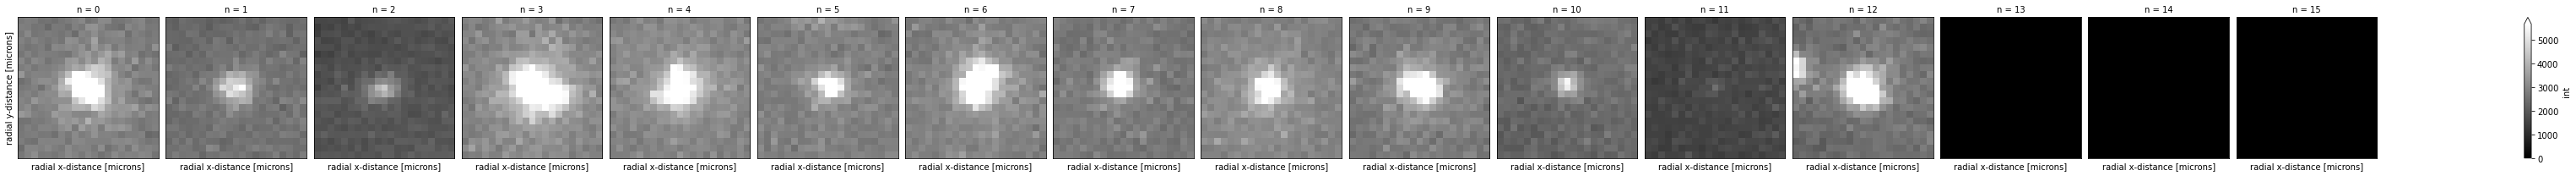

In [30]:
my_ca.ds["int"].max(dim="z").isel(fov=0, ch=2, n=slice(0,20), t=0).plot.imshow(col="n", cmap="gray", robust=True, xticks=[], yticks=[])